# Understanding Learning Curves

Now that you’ve learned how to implement fine-tuning using both the `Trainer` API and custom training loops, it’s crucial to understand how to interpret the results. Learning curves are invaluable tools that help you evaluate your model’s performance during training and identify potential issues before they reduce performance.

In this section, we’ll explore how to read and interpret accuracy and loss curves, understand what different curve shapes tell us about our model’s behavior, and learn how to address common training issues.

## What are Learning Curves?

Learning curves are visual representations of your model’s performance metrics over time during training. The two most important curves to monitor are:

- Loss curves: Show how the model’s error (loss) changes over training steps or epochs
- Accuracy curves: Show the percentage of correct predictions over training steps or epochs

These curves help us understand whether our model is learning effectively and can guide us in making adjustments to improve performance. In Transformers, these metrics are individually computed for each batch and then logged to the disk. We can then use libraries like [Weights & Biases](https://wandb.ai/) to visualize these curves and track our model’s performance over time.

### Loss Curves

The loss curve shows how the model’s error decreases over time. In a typical successful training run, you’ll see a curve similar to the one below:

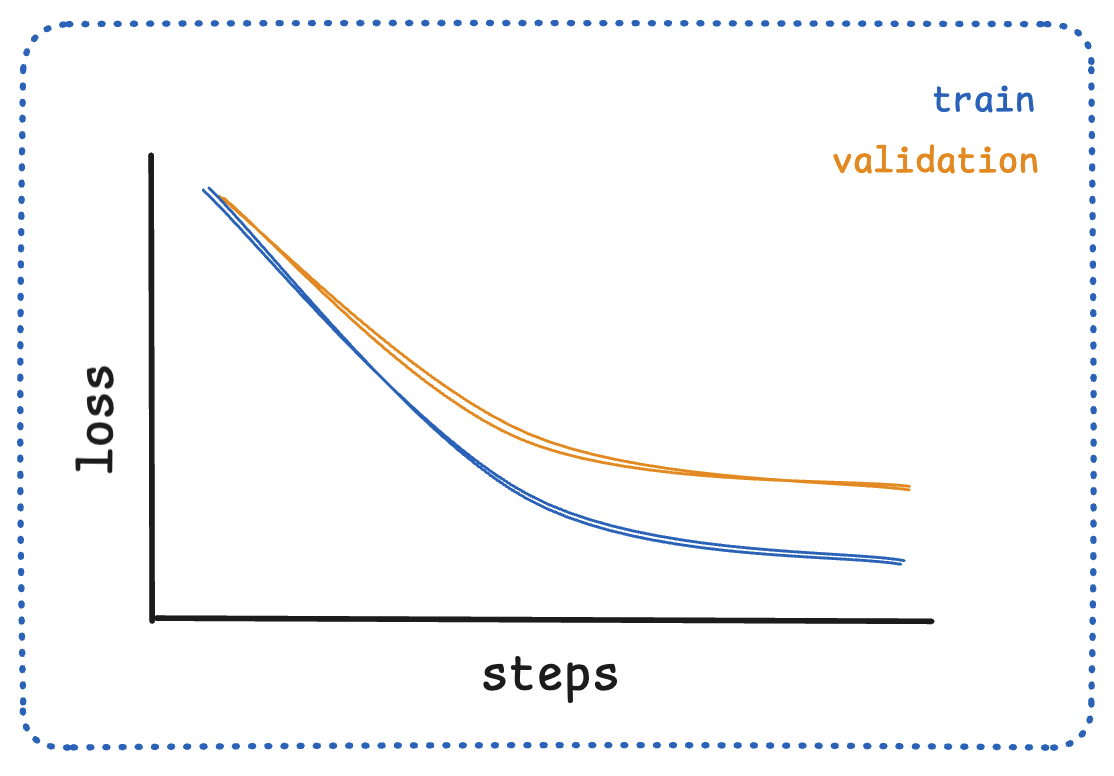

- **High initial loss:** The model starts without optimization, so predictions are initially poor
- **Decreasing loss:** As training progresses, the loss should generally decrease
- **Convergence:** Eventually, the loss stabilizes at a low value, indicating that the model has learned the patterns in the data

---

As in previous chapters, we can use the `Trainer` API to track these metrics and visualize them in a dashboard. Below is an example of how to do this with Weights & Biases.

In [1]:
from datasets import load_dataset

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")

In [2]:
from transformers import AutoTokenizer

ckpt = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [3]:
tokenized_datasets = raw_datasets.map(
    lambda x: tokenizer(x['sentence1'], x['sentence2'], truncation=True), 
    batched=True,
    batch_size=32
)

In [4]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    pad_to_multiple_of=8
)

**Example of tracking loss during training with the Trainer:**

In [ ]:
from transformers import TrainingArguments
from transformers import Trainer

import wandb

# Initialize Weights & Biases for experiment tracking
wandb.init(project="transformer-fine-tuning", name="bert-mrpc-analysis")

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=50,
    save_steps=100,
    logging_steps=10,  # Log metrics every 10 steps
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    report_to="wandb"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Train and automatically log metrics
trainer.train()